In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
import numpy as np
import matplotlib.pyplot as plt
def processSignals(ref, echo, burst_len, num_steps):
    #signal_ratio = echo*np.conjugate(ref);
    signal_ratio = echo/ref
    signal_ratio_reshaped = np.reshape(signal_ratio,[-1,burst_len])
    freq_response = np.mean(signal_ratio_reshaped, axis=1)
    s = freq_response * np.hamming(num_steps)
    s = np.fft.ifft(s)
    return freq_response, s

def B_scan(dir, prefix, burst_len, num_steps):
    supposed_size = burst_len*num_steps
    s_list = []
    for i in range(14):
        #print(i)
        fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
        fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
        
        ref_samples = np.fromfile(fileName_ref, np.complex64)
        N = supposed_size - ref_samples.size
        #print(ref_samples.size,N)
        if N>=0:
            ref_samples = np.pad(ref_samples,(0,N),'constant')
        else:
            ref_samples = ref_samples[0:supposed_size]
        
        rx_samples = np.fromfile(fileName_rx, np.complex64)  
        N = supposed_size - rx_samples.size
        #print(rx_samples.size,N)
        if N>=0:
            rx_samples = np.pad(rx_samples,(0,N),'constant')
        else:
            rx_samples = rx_samples[0:supposed_size]
        
        f,s = processSignals(ref_samples, rx_samples, burst_len, num_steps)
        s_list.append(s)
    return np.stack(s_list, axis=0)   

def normaliseSignals(input_sammples,burst_len,num_steps):
    samples = np.reshape(input_sammples,[num_steps,-1])
    print(samples.shape)
    samples_real = np.real(samples)
    samples_imag = np.imag(samples)
    max_val = np.max(samples_real,axis=1)
    min_val = np.min(samples_real,axis=1)
    samples_real_normalised = 2*(np.transpose(samples_real)-min_val)/(max_val-min_val)-1
    samples_real_normalised = np.transpose(samples_real_normalised).ravel()
    max_val = np.max(samples_imag,axis=1)
    min_val = np.min(samples_imag,axis=1)
    samples_imag_normalised = 2*(np.transpose(samples_imag)-min_val)/(max_val-min_val)-1
    samples_imag_normalised = np.transpose(samples_imag_normalised).ravel()
    return samples_real_normalised+1j*samples_imag_normalised

(128, 2048)
(128, 2048)


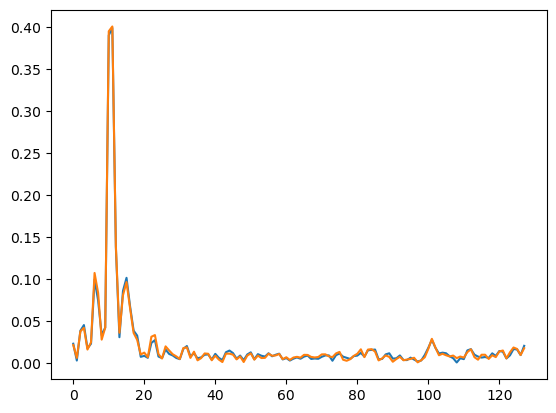

In [3]:
burst_len = 2048
num_steps = 128
supposed_size = burst_len*num_steps
dir = '../gui/'
prefix = 'cal'
i=2
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
ref_samples = np.fromfile(fileName_ref, np.complex64)
N = supposed_size - ref_samples.size
#print(ref_samples.size,N)
if N>=0:
    ref_samples = np.pad(ref_samples,(0,N),'constant')
else:
    ref_samples = ref_samples[0:supposed_size]

rx_samples = np.fromfile(fileName_rx, np.complex64)  
N = supposed_size - rx_samples.size
#print(rx_samples.size,N)
if N>=0:
    rx_samples = np.pad(rx_samples,(0,N),'constant')
else:
    rx_samples = rx_samples[0:supposed_size]

ref_complex_normalised = normaliseSignals(ref_samples,burst_len,num_steps)
rx_complex_normalised = normaliseSignals(rx_samples,burst_len,num_steps)
f_cal,s_cal = processSignals(ref_samples,rx_samples,burst_len,num_steps)
f_cal_norm,s_cal_norm = processSignals(ref_complex_normalised, rx_complex_normalised, burst_len, num_steps)
plt.plot(abs(s_cal))
plt.plot(abs(s_cal_norm))

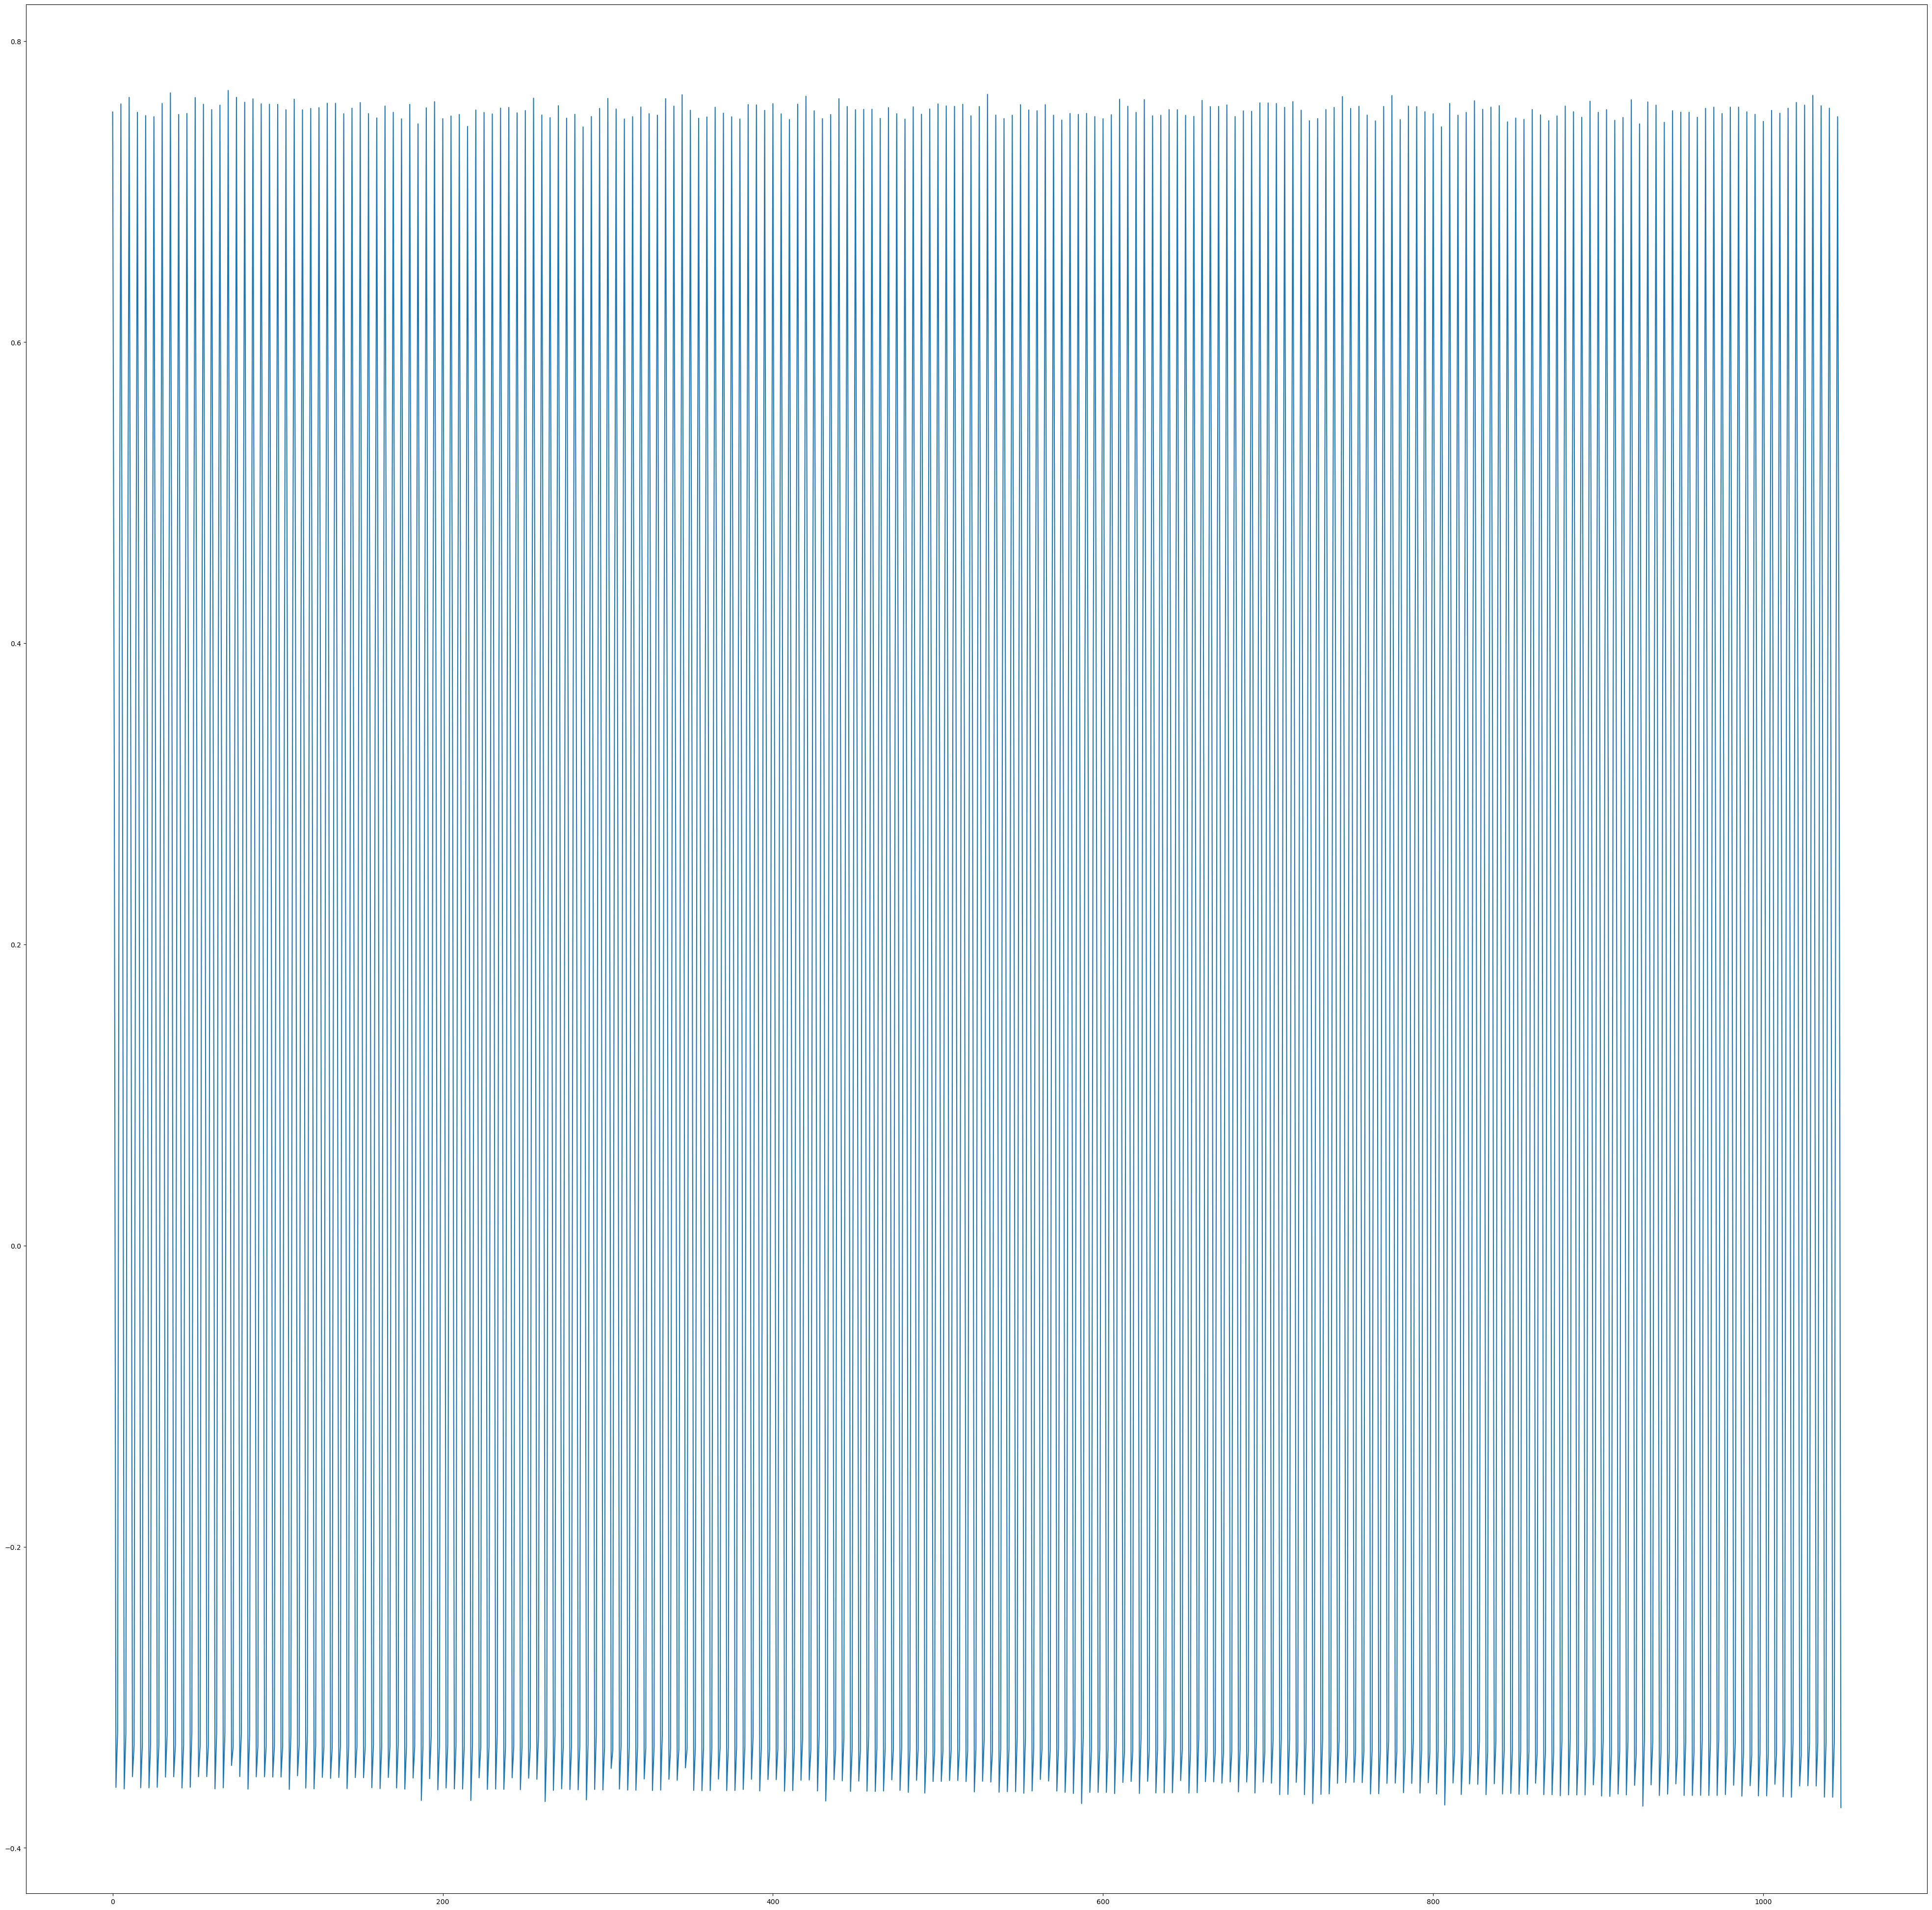

In [8]:
plt.figure(figsize=[50,50])
plt.plot(np.real(rx_samples[1000:2048]))

In [ ]:
burst_len = 2048
num_steps = 128
supposed_size = burst_len*num_steps
dir = '../gui/'
prefix = 'scan'
i=1
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
ref_samples = np.fromfile(fileName_ref, np.complex64)
N = supposed_size - ref_samples.size
#print(ref_samples.size,N)
if N>=0:
    ref_samples = np.pad(ref_samples,(0,N),'constant')
else:
    ref_samples = ref_samples[0:supposed_size]

rx_samples = np.fromfile(fileName_rx, np.complex64)  
N = supposed_size - rx_samples.size
#print(rx_samples.size,N)
if N>=0:
    rx_samples = np.pad(rx_samples,(0,N),'constant')
else:
    rx_samples = rx_samples[0:supposed_size]
ref_complex_normalised = normaliseSignals(ref_samples,burst_len,num_steps)
rx_complex_normalised = normaliseSignals(rx_samples,burst_len,num_steps)
# plt.figure(figsize=[80,10])
# plt.plot(rx_complex_normalised)

f_norm,s_norm = processSignals(ref_complex_normalised, rx_complex_normalised, burst_len, num_steps)
f,s = processSignals(ref_samples, rx_samples, burst_len, num_steps)

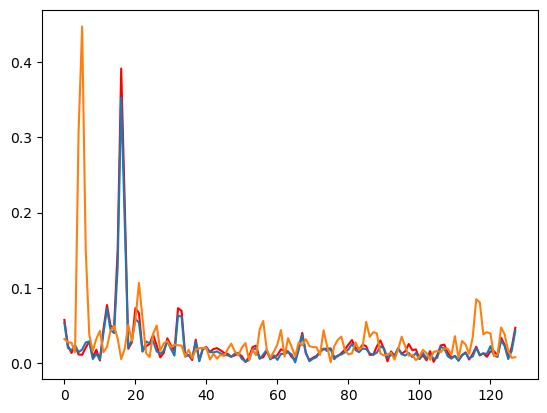

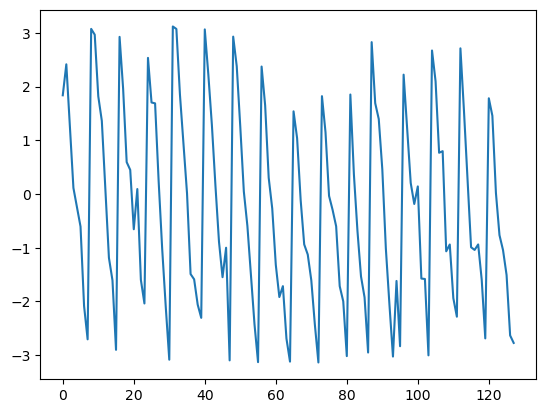

In [103]:
plt.plot(abs(s),color='red')
plt.plot(abs(s_norm))

#s_calibrated = s*np.conjugate(s_cal)
f_calibrated = f/f_cal
s_calibrated = f_calibrated * np.hamming(num_steps)
s_calibrated = np.fft.ifft(s_calibrated)

plt.plot(abs(s_calibrated))

plt.figure()
plt.plot(np.angle(f))

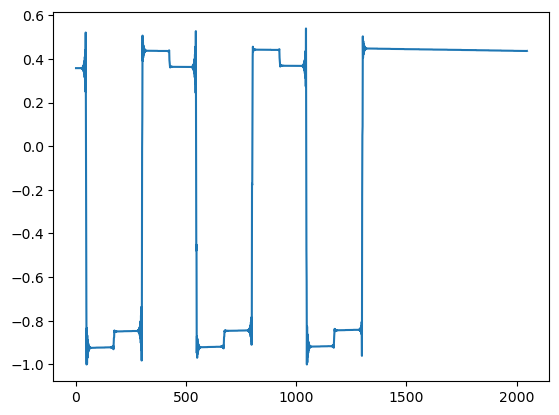

In [106]:
plt.plot(ref_samples[2048:4096])

In [14]:
ref_real = np.real(ref)
ref_imag = np.imag(ref)
ref_real_max = np.max(ref_real,axis=1)
ref_real_min = np.min(ref_real,axis=1)
ref_normalised_real = (ref_real-ref_real_min)/(ref_real_max - ref_real_min)
ref_normalised_real = np.reshape(ref_normalised_real,[2048*128,-1])
ref_normalised_imag = (ref_imag-np.min(ref_imag,axis=0))/(np.max(ref_imag,axis=0)-np.min(ref_imag,axis=0))
ref_normalised_imag = np.reshape(ref_normalised_imag,[2048*128,-1])

In [25]:
# plt.figure(figsize=[50,10])
# plt.plot(ref_normalised_real)
# i=2
# plt.plot(ref_real[i,:])
# plt.plot(ref_normalised_real[i,:])
ref_real = np.real(ref)
ref_imag = np.imag(ref)
ref_max = np.max(ref,axis=1)
ref_min = np.min(ref,axis=1)
ref_normalised = 2*(np.transpose(ref)-ref_min)/(ref_max - ref_min)-1

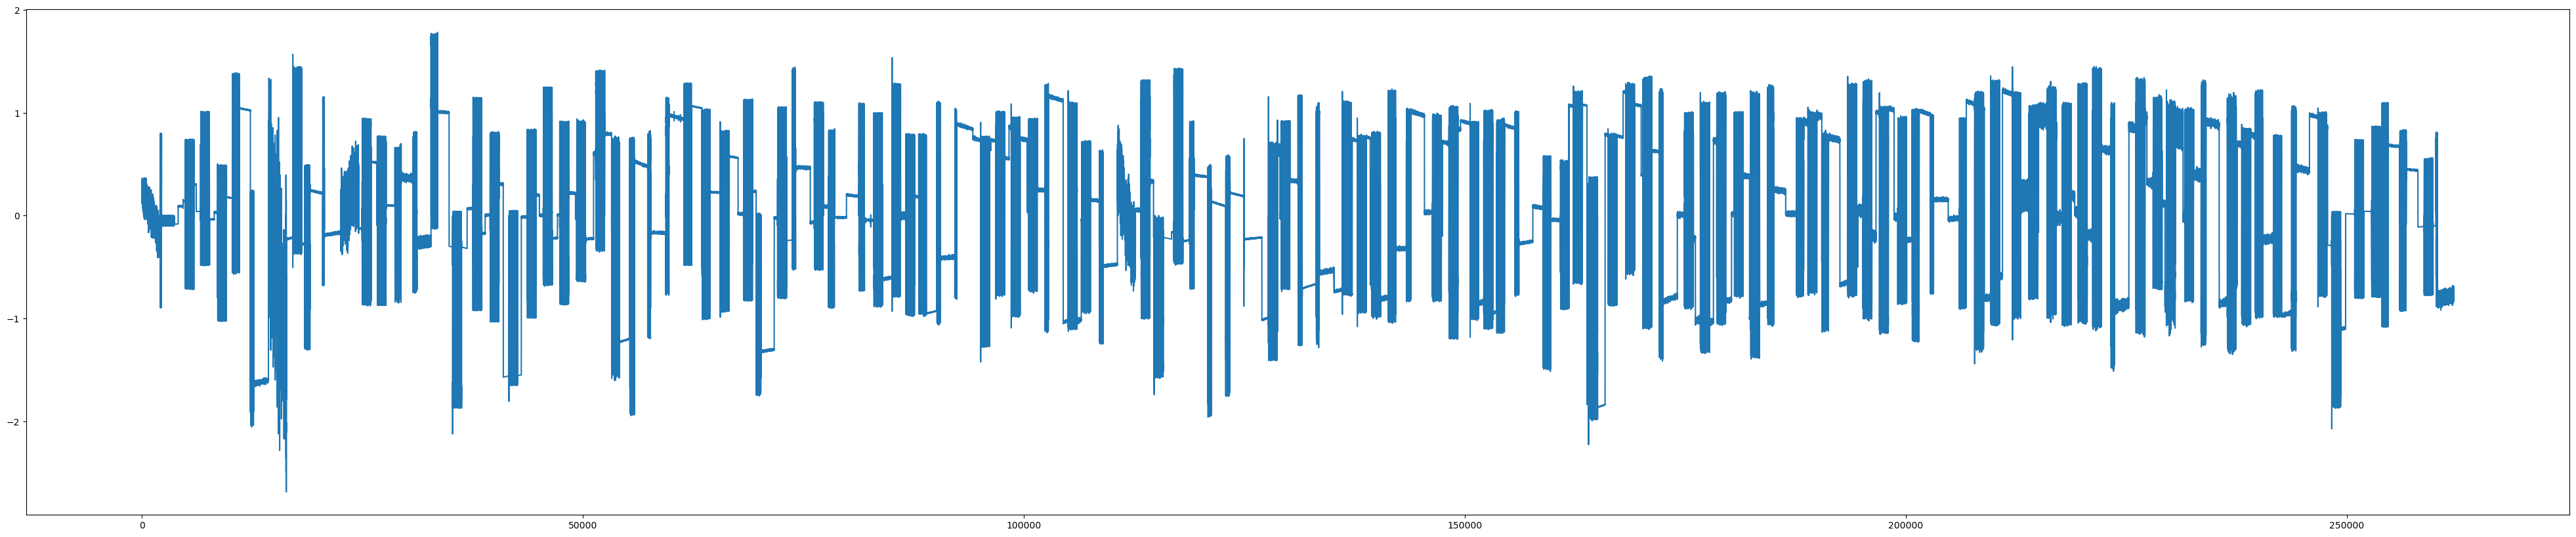

In [30]:
ref_normalised = np.transpose(ref_normalised).ravel()
plt.figure(figsize=[50,10])
plt.plot(np.imag(ref_normalised))

In [65]:
def normaliseSignals(input_sammples,burst_len,num_steps):
    samples = np.reshape(input_sammples,[num_steps,-1])
    print(samples.shape)
    samples_real = np.real(samples)
    samples_imag = np.imag(samples)
    max_val = np.max(samples_real,axis=1)
    min_val = np.min(samples_real,axis=1)
    samples_real_normalised = 2*(np.transpose(samples_real)-min_val)/(max_val-min_val)-1
    samples_real_normalised = np.transpose(samples_real_normalised).ravel()
    max_val = np.max(samples_imag,axis=1)
    min_val = np.min(samples_imag,axis=1)
    samples_imag_normalised = 2*(np.transpose(samples_imag)-min_val)/(max_val-min_val)-1
    samples_imag_normalised = np.transpose(samples_imag_normalised).ravel()
    return samples_real_normalised+1j*samples_imag_normalised

In [66]:
ref_complex_normalised = normaliseSignals(ref_samples,burst_len,num_steps)
rx_complex_normalised = normaliseSignals(rx_samples,burst_len,num_steps)

(128, 2048)
(128, 2048)


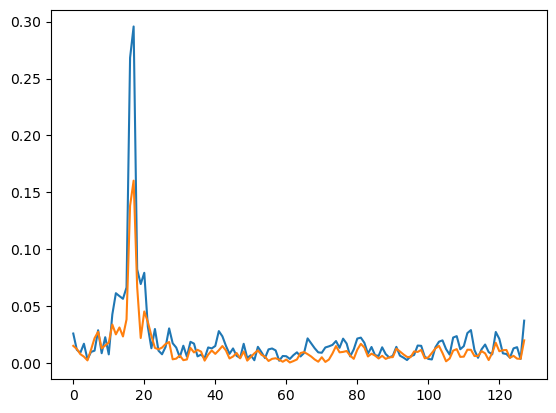

In [67]:
f,s  = processSignals(ref_complex_normalised,rx_complex_normalised,burst_len,num_steps)
plt.plot(np.abs(s))

f,s = processSignals(ref_samples,rx_samples,burst_len,num_steps)
plt.plot(np.abs(s))

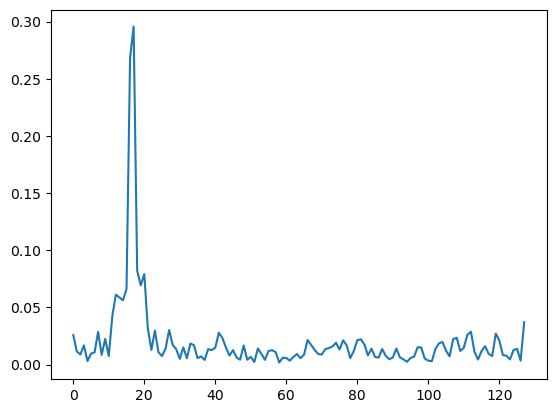

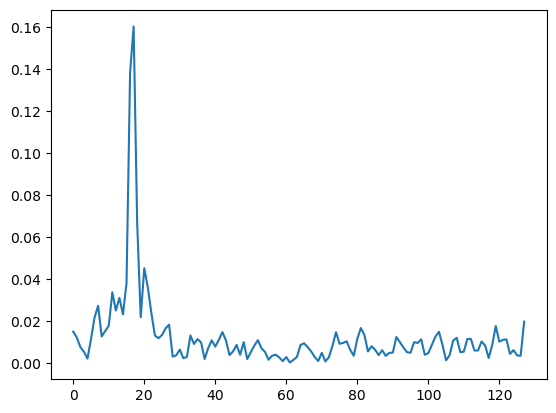

In [60]:
f,s = processSignals(ref_samples,rx_samples,burst_len,num_steps)
plt.plot(np.abs(s))